# Superstore Sales Analytics, Profit Prediction and Customer Segmentation Using Machine Learning

## AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026

### 1. Introduction

Data analytics helps organizations convert raw data into meaningful information for business decision-making. Retail organizations generate large amounts of transactional data containing information about customers, products, sales, discounts, regions and profitability.

This project analyzes the Superstore retail dataset to understand sales and profitability patterns, customer purchasing behavior, product performance and regional performance. Exploratory Data Analysis (EDA), statistical analysis, data visualization and machine-learning techniques are used to derive meaningful insights.

The project also applies supervised learning techniques for prediction and K-Means clustering for customer segmentation.

## 2. Problem Statement

The objective of this project is to analyze historical Superstore sales data and identify patterns related to sales, profit, customers, products and regions. The project also aims to use machine-learning techniques to predict sales-related outcomes and classify orders based on profitability, while using clustering to identify groups of customers with similar purchasing behavior.

## 3. Objectives

1. Understand and preprocess the Superstore dataset.
2. Check and handle data-quality issues such as missing values and duplicate records.
3. Perform exploratory data analysis on sales, profit, customers, products and regions.
4. Analyze trends using statistical summaries and visualizations.
5. Create useful features from the existing dataset.
6. Build a regression model for sales prediction.
7. Build a classification model for profitability prediction.
8. Apply a Decision Tree classifier and evaluate its performance.
9. Apply K-Means clustering for customer segmentation.
10. Generate business-oriented insights from the analytical results.
11. Prepare visualizations and dashboard-ready data for reporting.

## 3. Dataset

**Source:** Kaggle Superstore Dataset  
https://www.kaggle.com/datasets/divyjn28/superstore-dataset

The supplied workbook contains three sheets:
- `Orders` — main transaction-level data
- `Returns` — returned order information
- `People` — regional manager information

The `Orders` sheet is the primary analytical dataset.


In [102]:
# Import required libraries

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")

All libraries imported successfully.


In [103]:
# Load the Superstore dataset

file_path = "sample_-_superstore.xls"

orders = pd.read_excel(file_path, sheet_name="Orders")
returns = pd.read_excel(file_path, sheet_name="Returns")
people = pd.read_excel(file_path, sheet_name="People")

print("Orders shape:", orders.shape)
print("Returns shape:", returns.shape)
print("People shape:", people.shape)

Orders shape: (9994, 21)
Returns shape: (296, 2)
People shape: (4, 2)


In [104]:
# Display first five rows

orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [105]:
# Display last five rows

orders.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,Florida,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,California,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,2017-05-04,2017-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,California,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [106]:
# Display column names

orders.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [107]:
# Dataset information

orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [108]:
# Statistical summary

orders.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


In [109]:
# Number of unique values in each column

orders.nunique().sort_values(ascending=False)

Row ID           9994
Profit           7545
Sales            6144
Order ID         5009
Product ID       1862
Product Name     1850
Ship Date        1334
Order Date       1237
Customer ID       793
Customer Name     793
Postal Code       631
City              531
State              49
Sub-Category       17
Quantity           14
Discount           12
Ship Mode           4
Region              4
Segment             3
Category            3
Country             1
dtype: int64

In [110]:
# Check missing values

missing_values = orders.isnull().sum()

print("Missing values in each column:")
display(missing_values)

Missing values in each column:


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [111]:
# Missing-value percentage

missing_percentage = (orders.isnull().sum() / len(orders)) * 100

missing_table = pd.DataFrame({
    "Missing Values": orders.isnull().sum(),
    "Percentage": missing_percentage
})

display(missing_table)

,Missing Values,Percentage
Row ID,0,0.0
Order ID,0,0.0
Order Date,0,0.0
Ship Date,0,0.0
Ship Mode,0,0.0
Customer ID,0,0.0
Customer Name,0,0.0
Segment,0,0.0
Country,0,0.0
City,0,0.0


In [112]:
# Check duplicate records

duplicate_count = orders.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [113]:
# Check data types

orders.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [114]:
# Convert date columns to datetime

orders["Order Date"] = pd.to_datetime(
    orders["Order Date"],
    errors="coerce"
)

orders["Ship Date"] = pd.to_datetime(
    orders["Ship Date"],
    errors="coerce"
)

print(orders[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


In [115]:
#This is our Feature Engineering section.
# Create date-based features

orders["Year"] = orders["Order Date"].dt.year
orders["Month"] = orders["Order Date"].dt.month
orders["Month Name"] = orders["Order Date"].dt.month_name()
orders["Quarter"] = orders["Order Date"].dt.quarter

# Calculate shipping duration

orders["Shipping Days"] = (
    orders["Ship Date"] - orders["Order Date"]
).dt.days

# Calculate profit margin

orders["Profit Margin"] = np.where(
    orders["Sales"] != 0,
    (orders["Profit"] / orders["Sales"]) * 100,
    0
)

# Create profitability classification

orders["Profitability"] = np.where(
    orders["Profit"] > 0,
    "Profitable",
    "Non-Profitable"
)

orders.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Month Name,Quarter,Shipping Days,Profit Margin,Profitability
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,4,3,16.00,Profitable
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,4,3,30.00,Profitable
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2,4,47.00,Profitable
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,4,7,-40.00,Non-Profitable
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,4,7,11.25,Profitable


In [116]:
# Basic KPIs
# Calculate key business metrics

total_sales = orders["Sales"].sum()
total_profit = orders["Profit"].sum()
total_quantity = orders["Quantity"].sum()

total_orders = orders["Order ID"].nunique()
total_customers = orders["Customer ID"].nunique()
total_products = orders["Product ID"].nunique()

average_order_value = (
    orders.groupby("Order ID")["Sales"].sum().mean()
)

print("========== SUPERSTORE KPIs ==========")
print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Total Profit      : ${total_profit:,.2f}")
print(f"Total Quantity    : {total_quantity:,}")
print(f"Total Orders      : {total_orders:,}")
print(f"Total Customers   : {total_customers:,}")
print(f"Total Products    : {total_products:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")

========== SUPERSTORE KPIs ==========
Total Sales       : $2,297,200.86
Total Profit      : $286,397.02
Total Quantity    : 37,873
Total Orders      : 5,009
Total Customers   : 793
Total Products    : 1,862
Average Order Value: $458.61


In [117]:
# Sales and profit by category

category_summary = (
    orders.groupby("Category")[["Sales", "Profit", "Quantity"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

display(category_summary)

,Sales,Profit,Quantity
Category,,,
Technology,836154.0330,145454.9481,6939
Furniture,741999.7953,18451.2728,8028
Office Supplies,719047.0320,122490.8008,22906


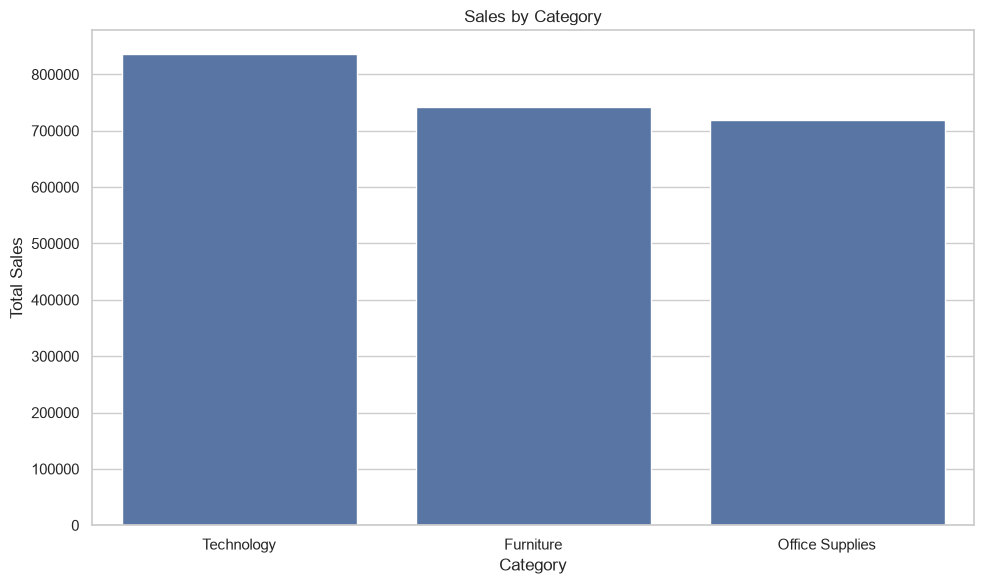

In [118]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_summary.reset_index(),
    x="Category",
    y="Sales"
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

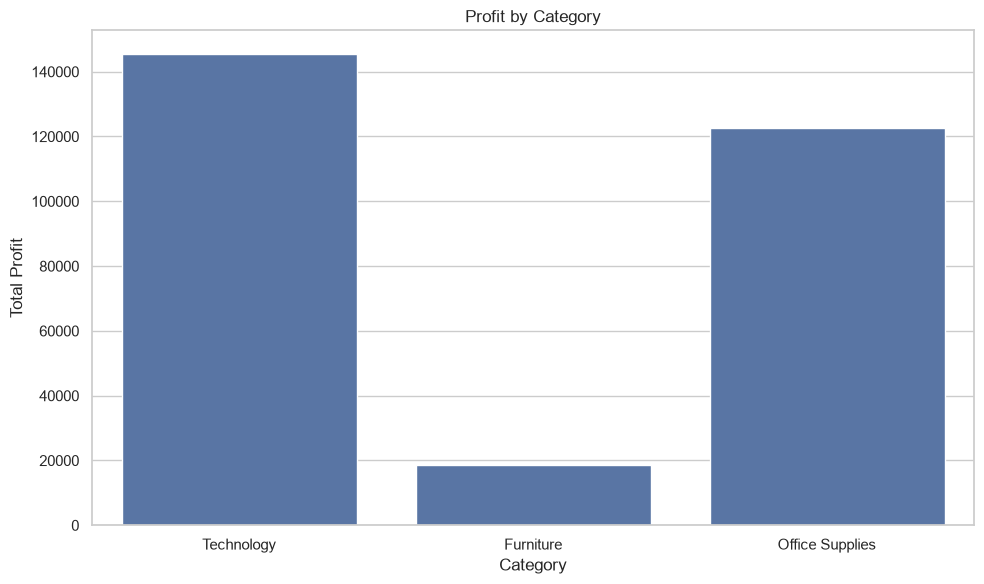

In [119]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_summary.reset_index(),
    x="Category",
    y="Profit"
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.show()

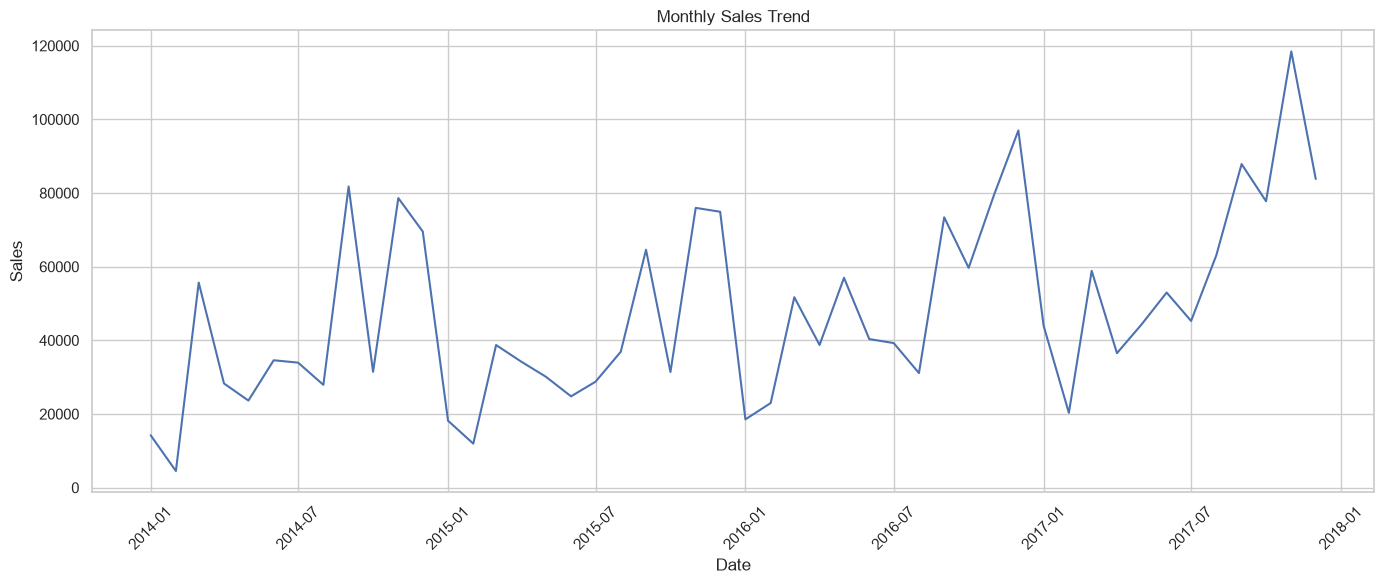

In [120]:
# Monthly sales trend

monthly_sales = (
    orders.set_index("Order Date")
    .resample("MS")["Sales"]
    .sum()
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [121]:
yearly_sales = (
    orders.groupby("Year")["Sales"]
    .sum()
)

display(yearly_sales)

Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

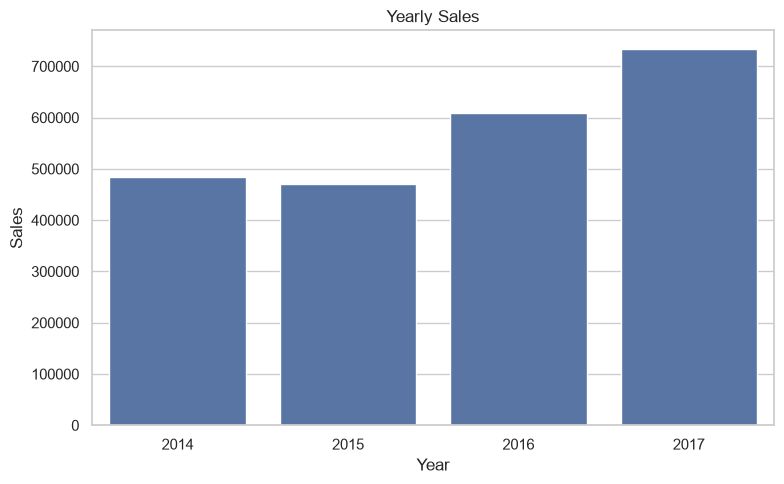

In [122]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=yearly_sales.index,
    y=yearly_sales.values
)

plt.title("Yearly Sales")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.tight_layout()
plt.show()

In [123]:
region_summary = (
    orders.groupby("Region")[["Sales", "Profit"]]
    .sum()
    .sort_values("Profit", ascending=False)
)

display(region_summary)

,Sales,Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
South,391721.9050,46749.4303
Central,501239.8908,39706.3625


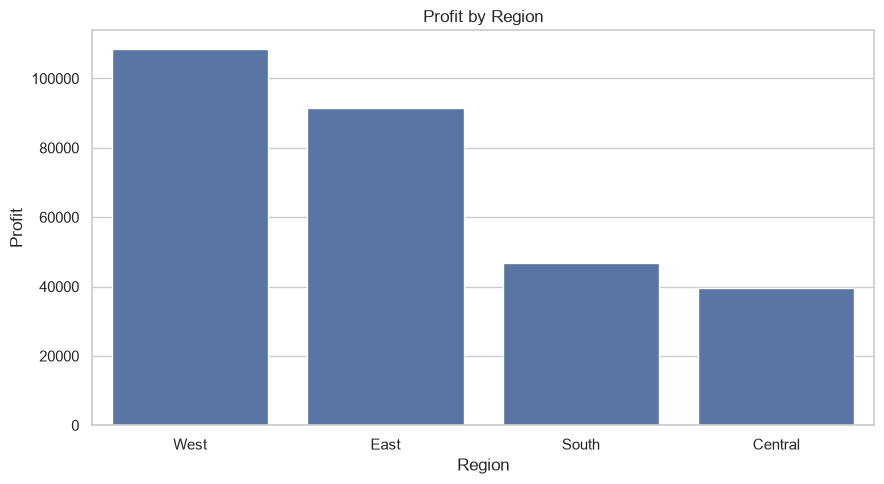

In [124]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=region_summary.reset_index(),
    x="Region",
    y="Profit"
)

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [125]:
sub_category_summary = (
    orders.groupby("Sub-Category")[["Sales", "Profit"]]
    .sum()
    .sort_values("Sales", ascending=False)
)

display(sub_category_summary)

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


In [126]:
top_10_subcategories = sub_category_summary.head(10)

display(top_10_subcategories)

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


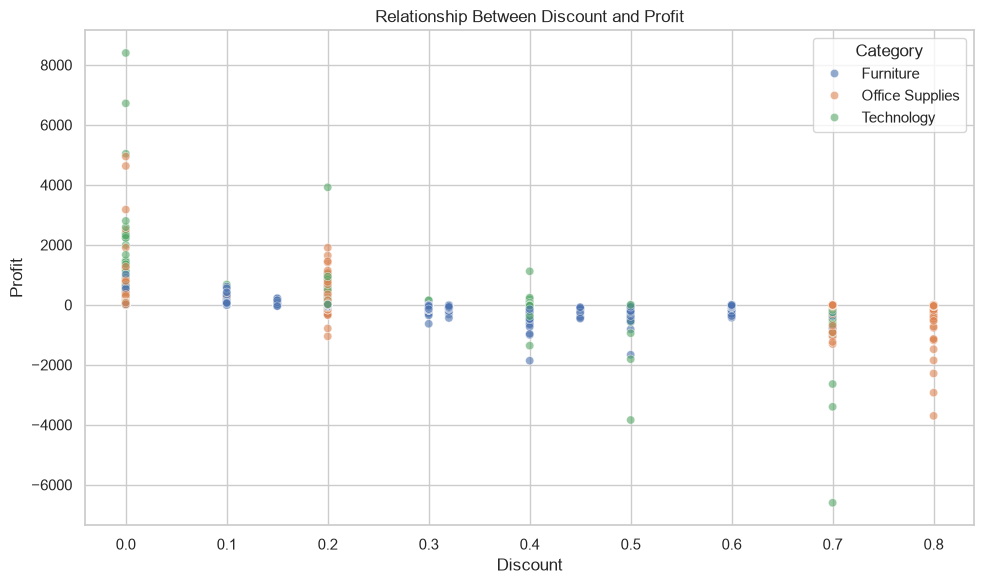

In [127]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=orders,
    x="Discount",
    y="Profit",
    hue="Category",
    alpha=0.6
)

plt.title("Relationship Between Discount and Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [128]:
discount_profit_corr = orders["Discount"].corr(
    orders["Profit"]
)

print(
    f"Correlation between Discount and Profit: "
    f"{discount_profit_corr:.4f}"
)

Correlation between Discount and Profit: -0.2195


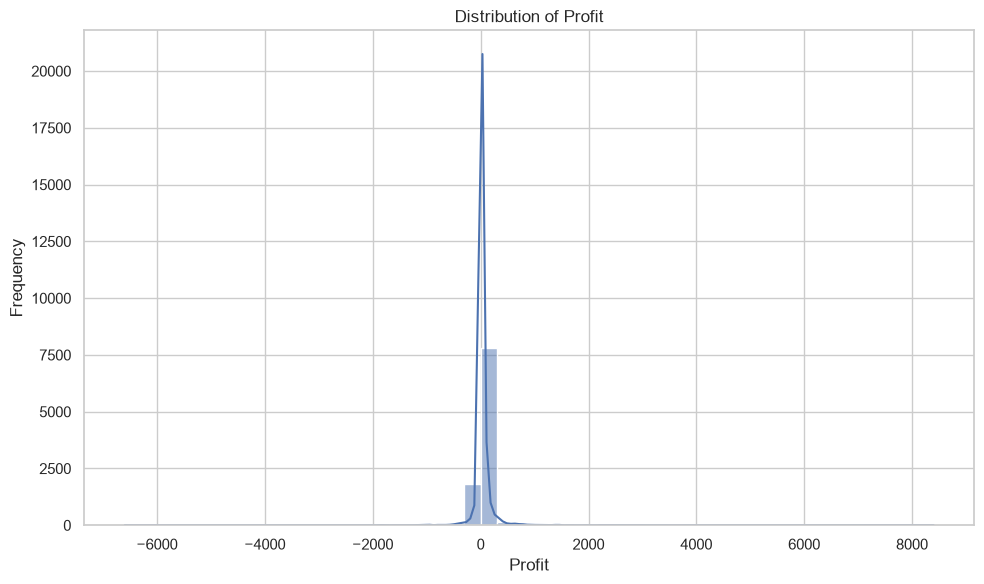

In [129]:
plt.figure(figsize=(10, 6))

sns.histplot(
    orders["Profit"],
    bins=50,
    kde=True
)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [130]:
profitability_counts = orders["Profitability"].value_counts()

display(profitability_counts)

Profitability
Profitable        8058
Non-Profitable    1936
Name: count, dtype: int64

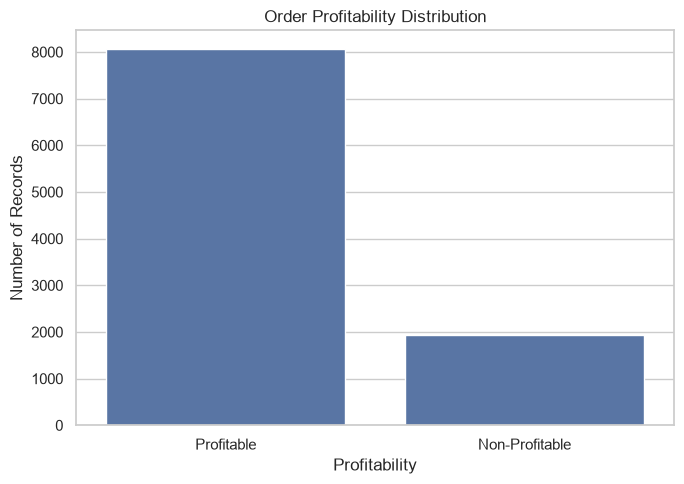

In [131]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=orders,
    x="Profitability"
)

plt.title("Order Profitability Distribution")
plt.xlabel("Profitability")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

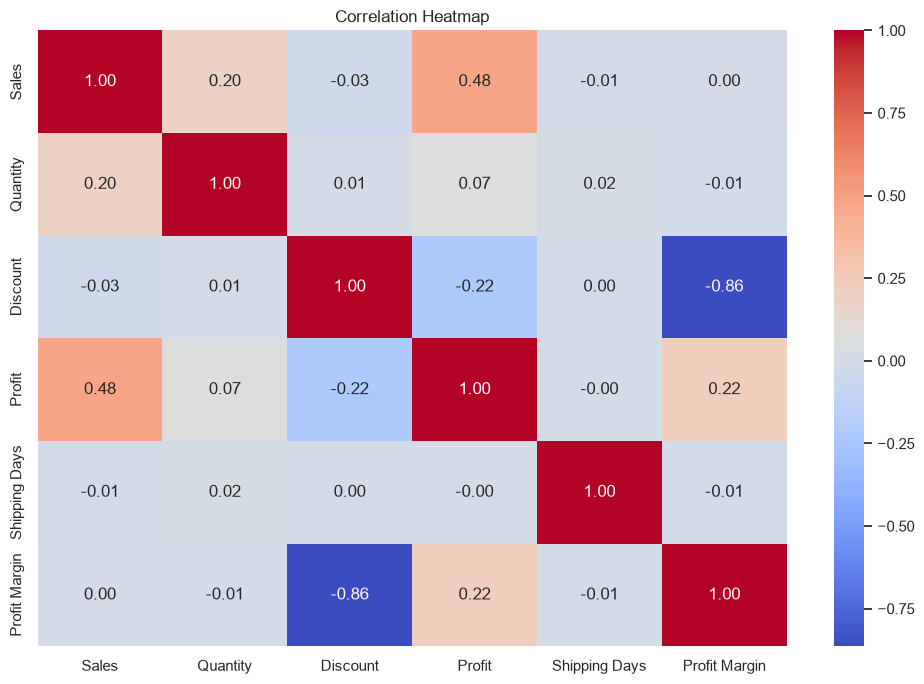

In [132]:
numeric_columns = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Days",
    "Profit Margin"
]

correlation_matrix = orders[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show() 

# 21. Machine Learning and Predictive Analytics

Machine learning is used in this project to identify patterns in historical Superstore data and make predictions.

Three approaches are used:

1. **Regression** — predict Sales.
2. **Classification** — predict whether an order is Profitable or Non-Profitable.
3. **Clustering** — segment customers according to purchasing behavior.

The dataset is divided into training and testing sets for supervised learning. The training data is used to learn patterns, while the testing data is used to evaluate how the model performs on unseen data.

Regression: Sales Prediction
Prepare the regression dataset

In [133]:
# Features for Sales prediction

regression_features = [
    "Quantity",
    "Discount",
    "Shipping Days",
    "Ship Mode",
    "Segment",
    "Region",
    "Category",
    "Sub-Category"
]

X_reg = orders[regression_features]

y_reg = orders["Sales"]

print("Feature shape:", X_reg.shape)
print("Target shape:", y_reg.shape)

display(X_reg.head())

Feature shape: (9994, 8)
Target shape: (9994,)


,Quantity,Discount,Shipping Days,Ship Mode,Segment,Region,Category,Sub-Category
0,2,0.00,3,Second Class,Consumer,South,Furniture,Bookcases
1,3,0.00,3,Second Class,Consumer,South,Furniture,Chairs
2,2,0.00,4,Second Class,Corporate,West,Office Supplies,Labels
3,5,0.45,7,Standard Class,Consumer,South,Furniture,Tables
4,2,0.20,7,Standard Class,Consumer,South,Office Supplies,Storage


In [134]:
# Split data into training and testing sets

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train_reg))
print("Testing records :", len(X_test_reg))

Training records: 7995
Testing records : 1999


In [135]:
# Numerical features

regression_numeric = [
    "Quantity",
    "Discount",
    "Shipping Days"
]

# Categorical features

regression_categorical = [
    "Ship Mode",
    "Segment",
    "Region",
    "Category",
    "Sub-Category"
]

print("Numerical features:")
print(regression_numeric)

print("\nCategorical features:")
print(regression_categorical)

Numerical features:
['Quantity', 'Discount', 'Shipping Days']

Categorical features:
['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']


In [136]:
# Preprocessing pipeline

regression_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            regression_numeric
        ),

        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            regression_categorical
        )
    ]
)

In [137]:
# Create Linear Regression pipeline

regression_model = Pipeline([
    ("preprocessor", regression_preprocessor),
    ("model", LinearRegression())
])

# Train model

regression_model.fit(
    X_train_reg,
    y_train_reg
)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [138]:
# Predict Sales on test data

y_pred_reg = regression_model.predict(
    X_test_reg
)

print("First 10 actual Sales values:")
print(y_test_reg.head(10).values)

print("\nFirst 10 predicted Sales values:")
print(y_pred_reg[:10])

First 10 actual Sales values:
[563.808  36.672  37.3   212.058 171.288  99.136 340.182  17.38   22.62
  71.632]

First 10 predicted Sales values:
[ 236.66528371   59.73551397   75.14733722  456.84448536  590.39919279
   29.37259078  246.02445792  179.83777083 -108.00943437  353.12476522]


In [139]:
# Regression evaluation

mae = mean_absolute_error(
    y_test_reg,
    y_pred_reg
)

mse = mean_squared_error(
    y_test_reg,
    y_pred_reg
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test_reg,
    y_pred_reg
)

print("========== REGRESSION RESULTS ==========")

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

========== REGRESSION RESULTS ==========
MAE  : 226.31
MSE  : 480704.47
RMSE : 693.33
R²   : 0.1862


In [140]:
regression_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R2"
    ],
    "Value": [
        mae,
        mse,
        rmse,
        r2
    ]
})

display(regression_results)

,Metric,Value
0,MAE,226.307256
1,MSE,480704.466078
2,RMSE,693.328541
3,R2,0.186211


Actual vs Predicted Sales

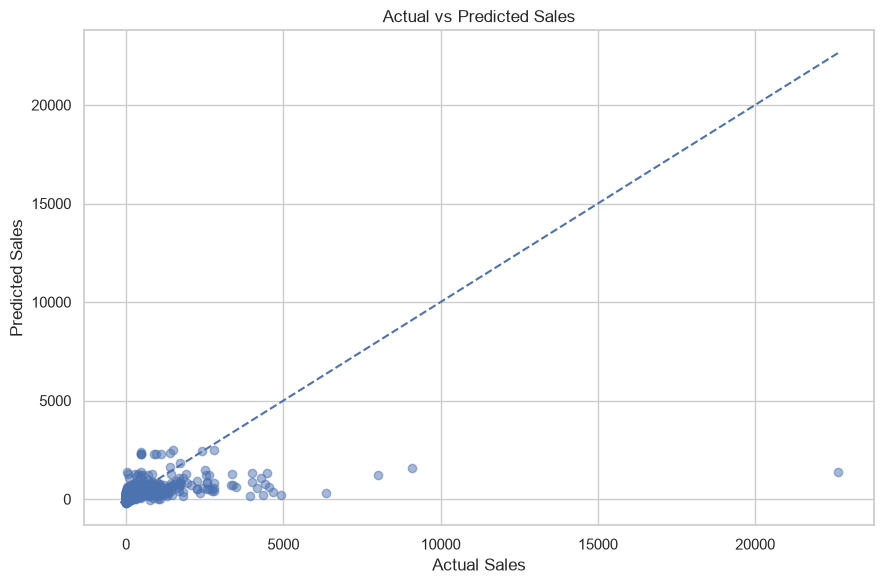

In [141]:
plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.5
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales"
)

# Reference line

minimum = min(
    y_test_reg.min(),
    y_pred_reg.min()
)

maximum = max(
    y_test_reg.max(),
    y_pred_reg.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.tight_layout()
plt.show()

In [142]:
#Classification
orders["Profitability"]

0           Profitable
1           Profitable
2           Profitable
3       Non-Profitable
4           Profitable
             ...      
9989        Profitable
9990        Profitable
9991        Profitable
9992        Profitable
9993        Profitable
Name: Profitability, Length: 9994, dtype: str

In [143]:
# Check target distribution

profitability_counts = orders[
    "Profitability"
].value_counts()

display(profitability_counts)

Profitability
Profitable        8058
Non-Profitable    1936
Name: count, dtype: int64

In [144]:
profitability_percentage = (
    orders["Profitability"]
    .value_counts(normalize=True)
    * 100
)

display(
    profitability_percentage.round(2)
)

Profitability
Profitable        80.63
Non-Profitable    19.37
Name: proportion, dtype: float64

In [145]:
classification_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Shipping Days",
    "Ship Mode",
    "Segment",
    "Region",
    "Category",
    "Sub-Category"
]

X_clf = orders[
    classification_features
]

y_clf = orders[
    "Profitability"
]

print("Classification feature shape:", X_clf.shape)
print("Classification target shape:", y_clf.shape)

Classification feature shape: (9994, 9)
Classification target shape: (9994,)


In [146]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf,
    y_clf,
    test_size=0.20,
    random_state=42,
    stratify=y_clf
)

print("Training records:", len(X_train_clf))
print("Testing records :", len(X_test_clf))

Training records: 7995
Testing records : 1999


In [147]:
# Preprocessing
classification_numeric = [
    "Sales",
    "Quantity",
    "Discount",
    "Shipping Days"
]

classification_categorical = [
    "Ship Mode",
    "Segment",
    "Region",
    "Category",
    "Sub-Category"
]

classification_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="median")
                )
            ]),
            classification_numeric
        ),

        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            classification_categorical
        )
    ]
)

In [148]:
# Decision Tree Classifier
# Create Decision Tree classifier

decision_tree_model = Pipeline([
    (
        "preprocessor",
        classification_preprocessor
    ),

    (
        "model",
        DecisionTreeClassifier(
            max_depth=6,
            random_state=42,
            class_weight="balanced"
        )
    )
])

# Train model

decision_tree_model.fit(
    X_train_clf,
    y_train_clf
)

print(
    "Decision Tree model trained successfully."
)

Decision Tree model trained successfully.


In [149]:
# Make Classification Predictions

# Predict profitability

y_pred_clf = decision_tree_model.predict(
    X_test_clf
)

print("First 20 predictions:")
print(y_pred_clf[:20])

First 20 predictions:
['Profitable' 'Profitable' 'Profitable' 'Profitable' 'Profitable'
 'Profitable' 'Profitable' 'Profitable' 'Non-Profitable' 'Non-Profitable'
 'Profitable' 'Non-Profitable' 'Profitable' 'Profitable' 'Non-Profitable'
 'Non-Profitable' 'Profitable' 'Non-Profitable' 'Profitable'
 'Non-Profitable']


In [150]:
# Classification Evaluation

# We'll calculate:
# Accuracy
# Precision
# Recall
# F1-score

accuracy = accuracy_score(
    y_test_clf,
    y_pred_clf
)

precision = precision_score(
    y_test_clf,
    y_pred_clf,
    pos_label="Profitable"
)

recall = recall_score(
    y_test_clf,
    y_pred_clf,
    pos_label="Profitable"
)

f1 = f1_score(
    y_test_clf,
    y_pred_clf,
    pos_label="Profitable"
)

print("========== CLASSIFICATION RESULTS ==========")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

========== CLASSIFICATION RESULTS ==========
Accuracy  : 0.9015
Precision : 0.9910
Recall    : 0.8859
F1 Score  : 0.9355


In [151]:
classification_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

display(
    classification_results
)

,Metric,Value
0,Accuracy,0.901451
1,Precision,0.990978
2,Recall,0.885856
3,F1 Score,0.935473


In [152]:
print(
    classification_report(
        y_test_clf,
        y_pred_clf
    )
)

                precision    recall  f1-score   support

Non-Profitable       0.67      0.97      0.79       387
    Profitable       0.99      0.89      0.94      1612

      accuracy                           0.90      1999
     macro avg       0.83      0.93      0.86      1999
  weighted avg       0.93      0.90      0.91      1999



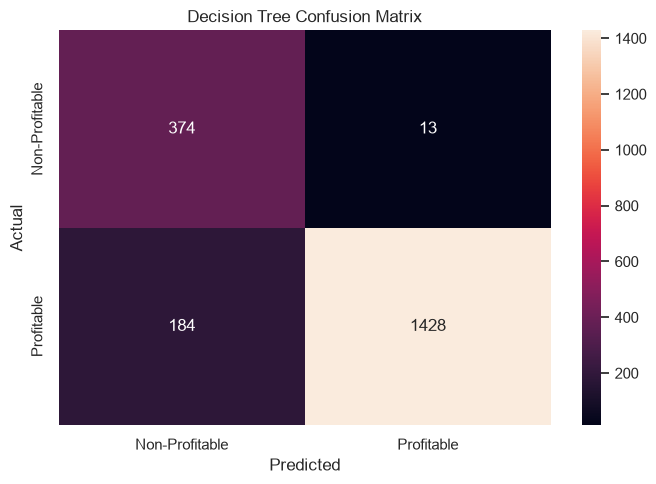

In [153]:
# Confusion Matrix

cm = confusion_matrix(
    y_test_clf,
    y_pred_clf,
    labels=[
        "Non-Profitable",
        "Profitable"
    ]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Non-Profitable",
        "Profitable"
    ],
    yticklabels=[
        "Non-Profitable",
        "Profitable"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.tight_layout()
plt.show()

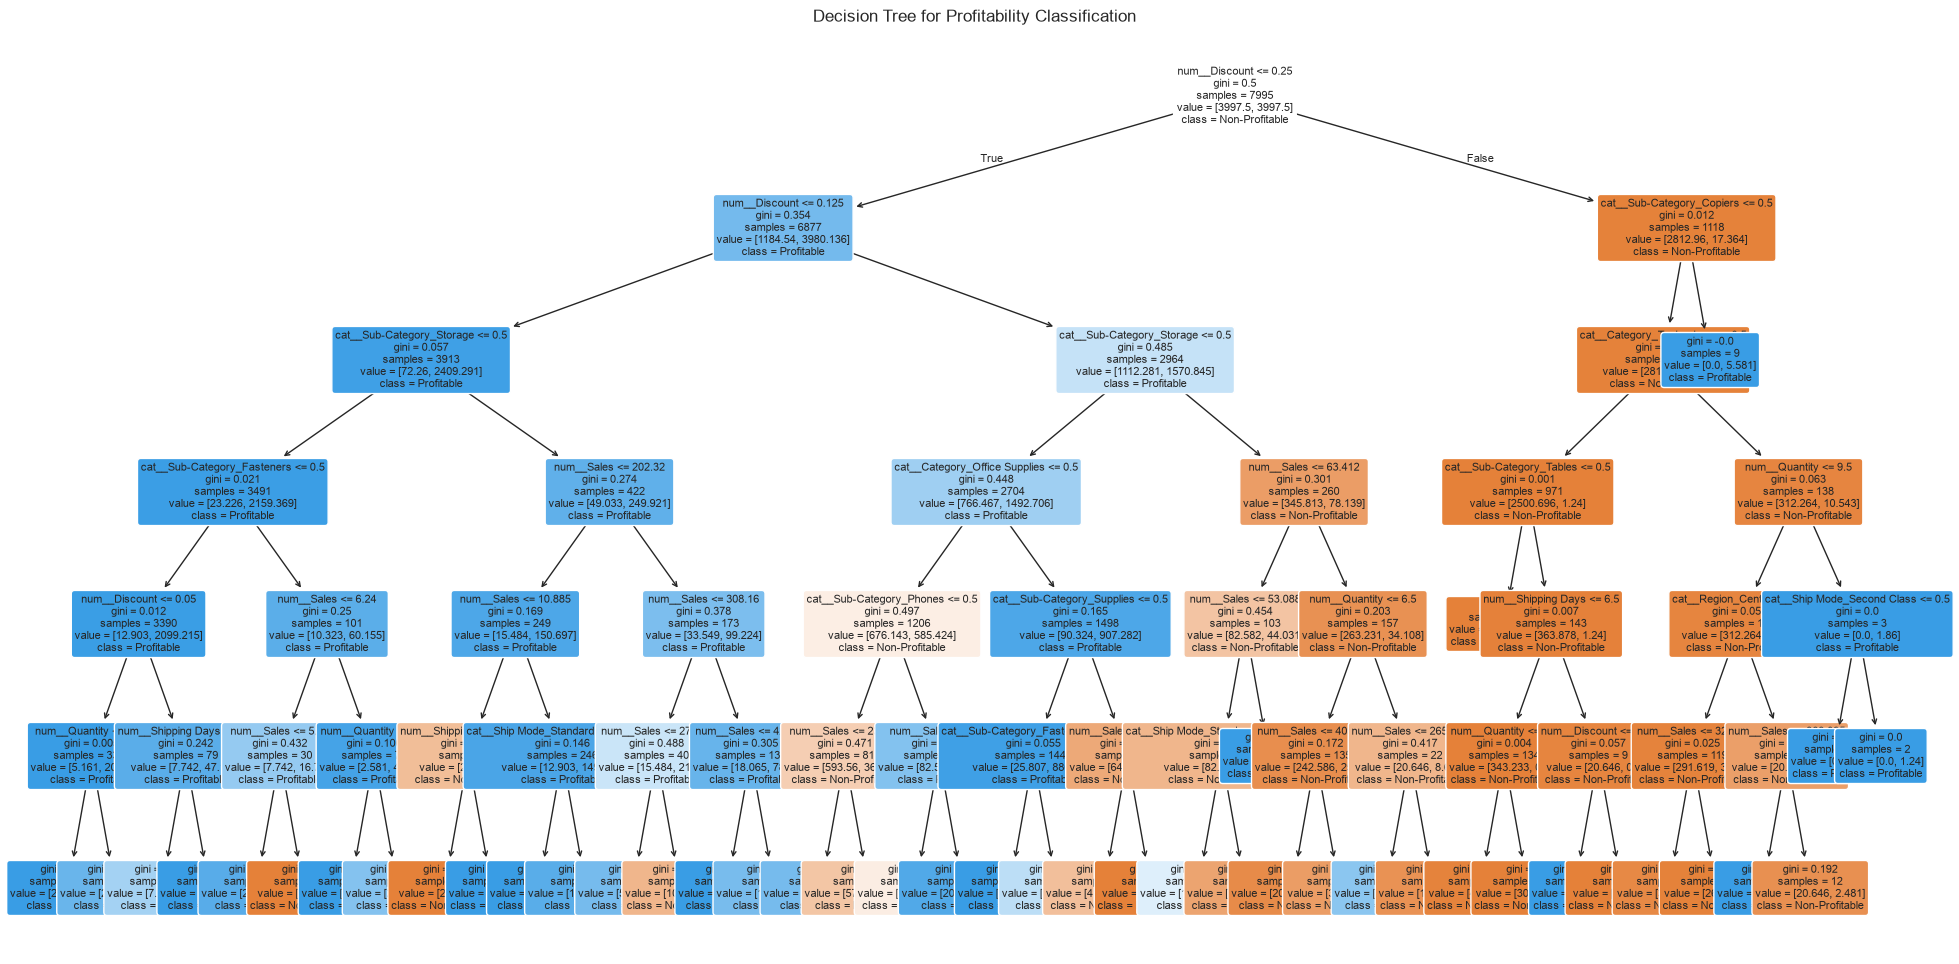

In [154]:
# Visualize the Decision Tree
# Extract transformed feature names

preprocessor = decision_tree_model.named_steps[
    "preprocessor"
]

tree = decision_tree_model.named_steps[
    "model"
]

feature_names = (
    preprocessor
    .get_feature_names_out()
)

plt.figure(figsize=(24, 12))

plot_tree(
    tree,
    feature_names=feature_names,
    class_names=[
        "Non-Profitable",
        "Profitable"
    ],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title(
    "Decision Tree for Profitability Classification"
)

plt.show()

In [155]:
# Customer Segmentation
# Create Customer Dataset

customer_data = (
    orders
    .groupby("Customer ID")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Order_Count=("Order ID", "nunique"),
        Average_Order_Value=("Sales", "mean")
    )
    .reset_index()
)

display(
    customer_data.head()
)

print(
    "Number of customers:",
    len(customer_data)
)


,Customer ID,Total_Sales,Total_Profit,Total_Quantity,Order_Count,Average_Order_Value
0,AA-10315,5563.560,-362.8825,30,5,505.778182
1,AA-10375,1056.390,277.3824,41,9,70.426000
2,AA-10480,1790.512,435.8274,36,4,149.209333
3,AA-10645,5086.935,857.8033,64,6,282.607500
4,AB-10015,886.156,129.3465,13,3,147.692667


Number of customers: 793


In [156]:
# Select Clustering Features
cluster_features = [
    "Total_Sales",
    "Total_Profit",
    "Total_Quantity",
    "Order_Count",
    "Average_Order_Value"
]

X_cluster = customer_data[
    cluster_features
]

display(
    X_cluster.head()
)

,Total_Sales,Total_Profit,Total_Quantity,Order_Count,Average_Order_Value
0,5563.560,-362.8825,30,5,505.778182
1,1056.390,277.3824,41,9,70.426000
2,1790.512,435.8274,36,4,149.209333
3,5086.935,857.8033,64,6,282.607500
4,886.156,129.3465,13,3,147.692667


In [157]:
# Standardize the Data

scaler = StandardScaler()

X_cluster_scaled = scaler.fit_transform(
    X_cluster
)

print(
    "Customer data standardized successfully."
)

Customer data standardized successfully.


In [158]:
# Find Suitable Number of Clusters

silhouette_scores = {}

for k in range(2, 7):

    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans_temp.fit_predict(
        X_cluster_scaled
    )

    score = silhouette_score(
        X_cluster_scaled,
        labels
    )

    silhouette_scores[k] = score

print("Silhouette Scores:")

for k, score in silhouette_scores.items():

    print(
        f"K = {k} → "
        f"Silhouette Score = {score:.4f}"
    )

Silhouette Scores:
K = 2 → Silhouette Score = 0.3672
K = 3 → Silhouette Score = 0.3487
K = 4 → Silhouette Score = 0.3215
K = 5 → Silhouette Score = 0.3087
K = 6 → Silhouette Score = 0.3140


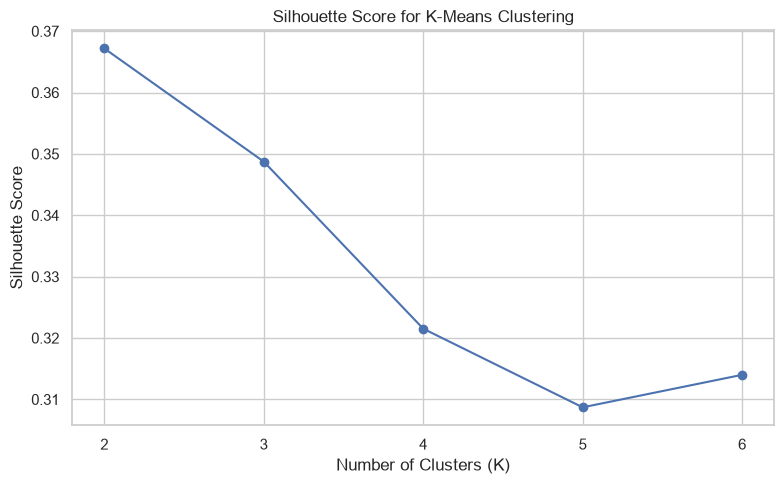

In [159]:
# Visualize Silhouette Scores

plt.figure(figsize=(8, 5))

plt.plot(
    list(silhouette_scores.keys()),
    list(silhouette_scores.values()),
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")

plt.title(
    "Silhouette Score for K-Means Clustering"
)

plt.xticks(
    list(silhouette_scores.keys())
)

plt.tight_layout()
plt.show()

In [160]:
# Select K Automatically

best_k = max(
    silhouette_scores,
    key=silhouette_scores.get
)

print(
    "Selected number of clusters:",
    best_k
)

Selected number of clusters: 2


In [161]:
# Train Final K-Means Model

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

customer_data["Cluster"] = kmeans.fit_predict(
    X_cluster_scaled
)

display(
    customer_data.head()
)

,Customer ID,Total_Sales,Total_Profit,Total_Quantity,Order_Count,Average_Order_Value,Cluster
0,AA-10315,5563.560,-362.8825,30,5,505.778182,1
1,AA-10375,1056.390,277.3824,41,9,70.426000,1
2,AA-10480,1790.512,435.8274,36,4,149.209333,1
3,AA-10645,5086.935,857.8033,64,6,282.607500,0
4,AB-10015,886.156,129.3465,13,3,147.692667,1


In [162]:
# Analyze the Clusters 

cluster_summary = (
    customer_data
    .groupby("Cluster")[cluster_features]
    .mean()
    .round(2)
)

display(
    cluster_summary
)

,Total_Sales,Total_Profit,Total_Quantity,Order_Count,Average_Order_Value
Cluster,,,,,
0,5142.92,788.45,70.82,8.51,314.77
1,1601.90,114.80,34.47,5.05,177.76


And count customers:

In [163]:
cluster_counts = (
    customer_data["Cluster"]
    .value_counts()
    .sort_index()
)

print("Customers in each cluster:")

display(
    cluster_counts
)

Customers in each cluster:


Cluster
0    290
1    503
Name: count, dtype: int64

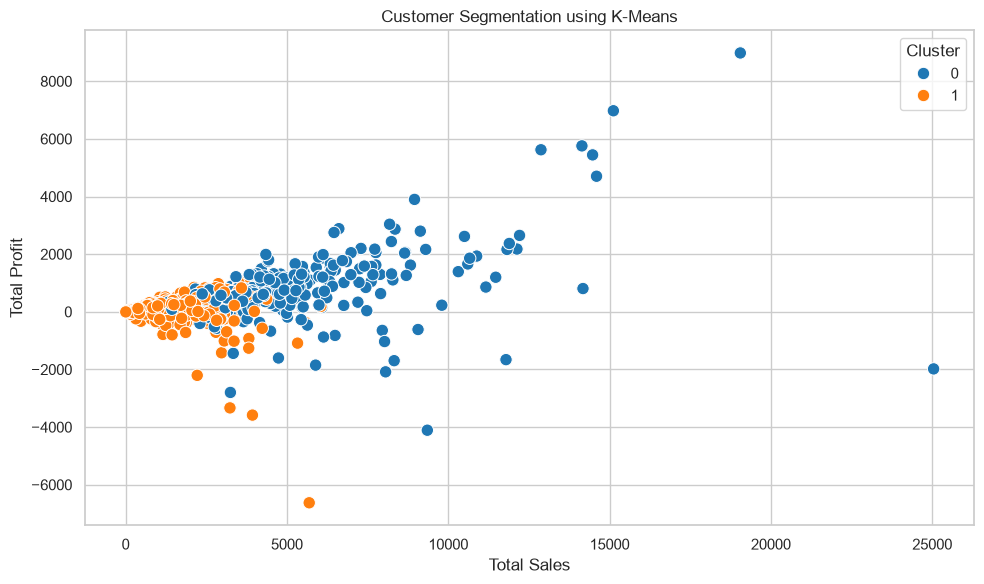

In [164]:
# Visualize Customer Segments

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=customer_data,
    x="Total_Sales",
    y="Total_Profit",
    hue="Cluster",
    palette="tab10",
    s=80
)

plt.title(
    "Customer Segmentation using K-Means"
)

plt.xlabel("Total Sales")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.show()

Create a Cluster Profile

In [165]:
cluster_profile = (
    customer_data
    .groupby("Cluster")
    .agg(
        Customers=("Customer ID", "count"),
        Avg_Sales=("Total_Sales", "mean"),
        Avg_Profit=("Total_Profit", "mean"),
        Avg_Quantity=("Total_Quantity", "mean"),
        Avg_Orders=("Order_Count", "mean"),
        Avg_Order_Value=("Average_Order_Value", "mean")
    )
    .round(2)
)

display(
    cluster_profile
)

,Customers,Avg_Sales,Avg_Profit,Avg_Quantity,Avg_Orders,Avg_Order_Value
Cluster,,,,,,
0,290,5142.92,788.45,70.82,8.51,314.77
1,503,1601.90,114.80,34.47,5.05,177.76


Export Our ML Results

In [166]:
# Save important outputs

regression_results.to_csv(
    "regression_results.csv",
    index=False
)

classification_results.to_csv(
    "classification_results.csv",
    index=False
)

customer_data.to_csv(
    "customer_segments.csv",
    index=False
)

cluster_profile.to_csv(
    "cluster_profile.csv",
    index=False
)

print("Machine learning results exported successfully.")

Machine learning results exported successfully.


Final ML Summary

In [167]:
print("==========================================")
print("       MACHINE LEARNING SUMMARY")
print("==========================================")

print("\nREGRESSION — SALES PREDICTION")
print("------------------------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

print("\nCLASSIFICATION — PROFITABILITY")
print("------------------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nCUSTOMER SEGMENTATION")
print("------------------------------------------")
print(f"Selected K: {best_k}")

print("\n==========================================")
print("Machine learning analysis completed.")
print("==========================================")

       MACHINE LEARNING SUMMARY

REGRESSION — SALES PREDICTION
------------------------------------------
MAE  : 226.31
RMSE : 693.33
R²   : 0.1862

CLASSIFICATION — PROFITABILITY
------------------------------------------
Accuracy  : 0.9015
Precision : 0.9910
Recall    : 0.8859
F1 Score  : 0.9355

CUSTOMER SEGMENTATION
------------------------------------------
Selected K: 2

Machine learning analysis completed.
